# Lesson 16 activity: feature engineering

## Notebook set up

Submit your notebook to the class leaderboard on HuggingFace at [huggingface.co/spaces/gperdrizet/leaderboard](https://huggingface.co/spaces/gperdrizet/leaderboard)

**Your task**: Apply at least two different feature engineering techniques to the `housing_df` dataframe to improve the dataset. At the end of the notebook, your engineered dataset and the original dataset will be used to train a linear regression model to predict `MedHouseVal`. Your goal is to achieve better model performance via feature engineering.

Don't change any of the code in the Model evaluation section of the notebook, especially the output saving. Otherwise the leaderboard scoring may not work!

Before applying transformations, explore the dataset to understand what techniques might be most beneficial.

### Import libraries

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

# Set random seed for reproducibility
np.random.seed(315)

### Load dataset

In [2]:
# Load California housing dataset
original_housing_df = pd.read_csv('https://media.githubusercontent.com/media/gperdrizet/fullstack-2605/refs/heads/main/data/california_housing.csv')
housing_df = original_housing_df.copy()

## Task 1: Explore the dataset

Before deciding what feature engineering techniques to apply, explore the dataset to understand its characteristics.

**Things to investigate**:
- Display basic information about the dataset (`.info()`, `.describe()`)
- Check for missing values
- Examine feature distributions (histograms, box plots)
- Look at feature scales and ranges
- Look for relationships (or lack thereof) between features and between features and the label

Use this exploration to inform your feature engineering decisions in the following tasks.

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None

             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   


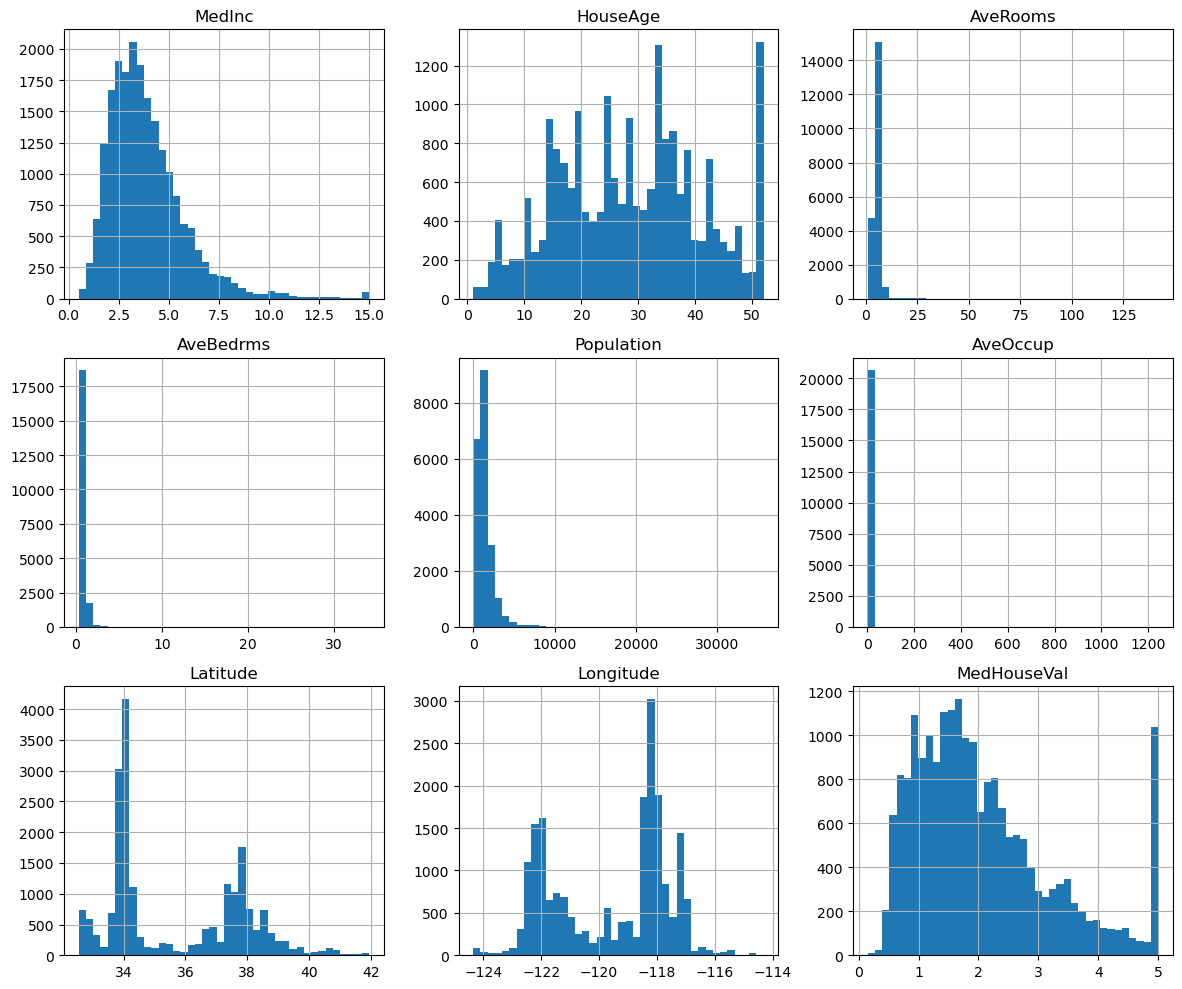


Skewness:
MedInc          1.646657
HouseAge        0.060331
AveRooms       20.697869
AveBedrms      31.316956
Population      4.935858
AveOccup       97.639561
Latitude        0.465953
Longitude      -0.297801
MedHouseVal     0.977763
dtype: float64

Correlation with MedHouseVal:
MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64


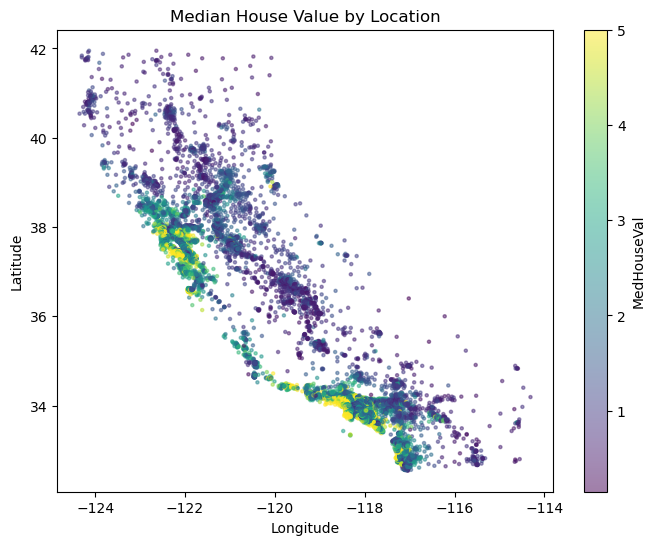

In [3]:
# Basic info and summary statistics
print(housing_df.info())
print()
print(housing_df.describe())

# Check for missing values
print('\nMissing values per column:')
print(housing_df.isnull().sum())

# Feature distributions
housing_df.hist(figsize=(12, 10), bins=40)
plt.tight_layout()
plt.show()

# Skewness of each feature
print('\nSkewness:')
print(housing_df.skew())

# Correlation with the target
print('\nCorrelation with MedHouseVal:')
print(housing_df.corr()['MedHouseVal'].sort_values(ascending=False))

# Geographic distribution of housing value
plt.figure(figsize=(8, 6))
plt.scatter(
    housing_df['Longitude'], housing_df['Latitude'],
    c=housing_df['MedHouseVal'], cmap='viridis', s=5, alpha=0.5
)
plt.colorbar(label='MedHouseVal')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Median House Value by Location')
plt.show()


## Task 2: Apply your first feature engineering technique

Based on your exploration, apply your first feature engineering technique.

**Example approaches**:
- Transform skewed features using log, sqrt, power, or quantile transformations
- Create bins/categories from continuous variables
- Create interaction features (e.g., rooms per household = total rooms / households)

Original skewness:
Population     4.935858
AveOccup      97.639561
AveRooms      20.697869
AveBedrms     31.316956
MedInc         1.646657
dtype: float64

Log-transformed skewness:
Population_log   -1.044087
AveOccup_log      3.879679
AveRooms_log      1.390761
AveBedrms_log     8.988786
MedInc_log        0.226083
dtype: float64


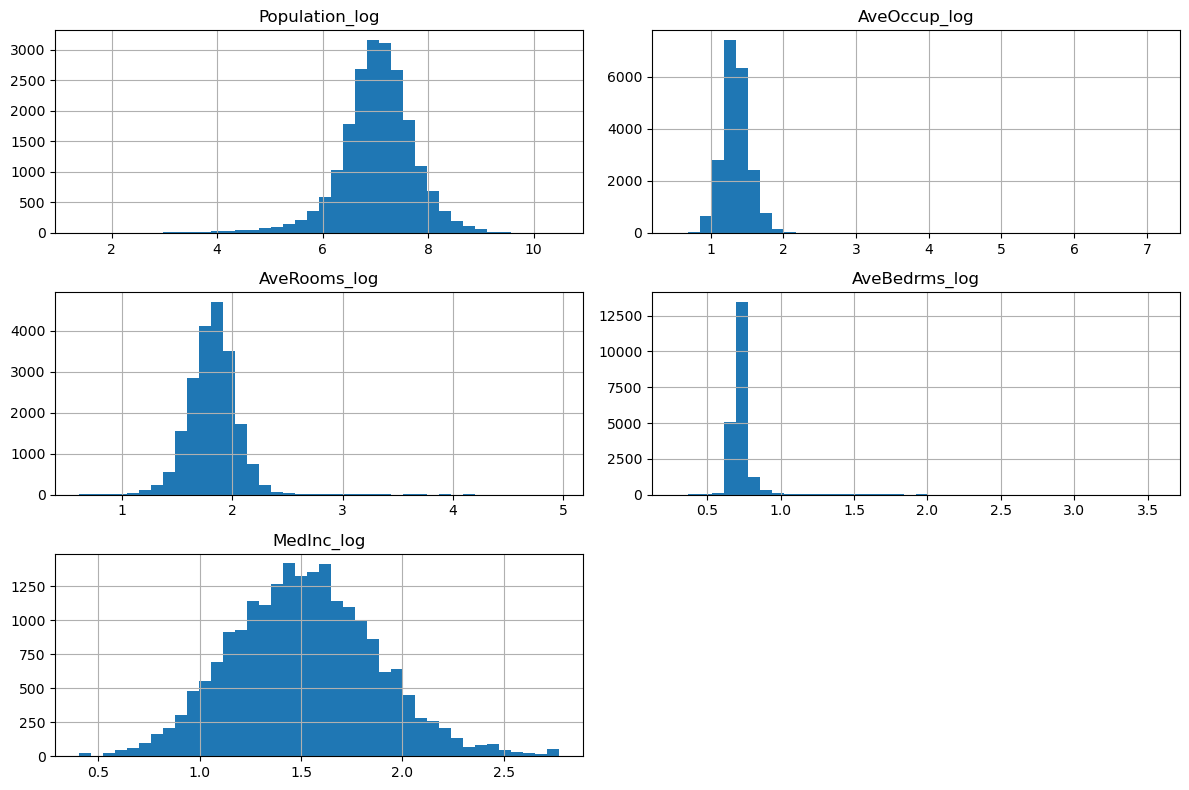

In [4]:
# Technique 1: log-transform heavily skewed features
#
# The exploration above shows Population, AveOccup, AveRooms, AveBedrms, and
# MedInc all have high skewness (several >5) and long right tails with extreme
# outliers (e.g. AveOccup). A linear model is sensitive to this - a few
# extreme block groups can dominate the fitted coefficients. Applying
# log1p() compresses the long tails and makes these features closer to
# normally distributed, which should give the linear model a more stable,
# linear relationship to work with.

skewed_features = ['Population', 'AveOccup', 'AveRooms', 'AveBedrms', 'MedInc']

for feature in skewed_features:
    housing_df[feature + '_log'] = np.log1p(housing_df[feature])

# Drop the original skewed columns so the model uses the transformed versions
housing_df = housing_df.drop(columns=skewed_features)

# Compare skewness before (original_housing_df) and after (housing_df)
print('Original skewness:')
print(original_housing_df[skewed_features].skew())

print('\nLog-transformed skewness:')
print(housing_df[[f + '_log' for f in skewed_features]].skew())

housing_df[[f + '_log' for f in skewed_features]].hist(figsize=(12, 8), bins=40)
plt.tight_layout()
plt.show()


## Task 3: Apply your second feature engineering technique

**Example approaches**:
- Scale features to similar ranges
- Encode any categorical variables you created
- Create aggregate statistics by groups

In [5]:
# Technique 2: derived interaction/ratio features
#
# Latitude/Longitude have only a weak individual linear correlation with
# MedHouseVal, but the geographic scatter plot shows housing value clearly
# increases near the coast and around major metro areas (LA, SF). We
# capture this with a "distance to nearest major city" feature. We also
# build a few interpretable ratio features (bedrooms per room, rooms per
# occupant, income per room) that often relate more directly to housing
# value than the raw averages alone.

# Distance to LA and SF (straight-line, in degrees) - use the smaller of the two
la_coords = (34.05, -118.24)
sf_coords = (37.77, -122.42)

dist_la = np.sqrt((housing_df['Latitude'] - la_coords[0])**2 + (housing_df['Longitude'] - la_coords[1])**2)
dist_sf = np.sqrt((housing_df['Latitude'] - sf_coords[0])**2 + (housing_df['Longitude'] - sf_coords[1])**2)
housing_df['dist_nearest_city'] = np.minimum(dist_la, dist_sf)

# Ratio features built from the original (pre-log) values
housing_df['bedrooms_ratio'] = original_housing_df['AveBedrms'] / original_housing_df['AveRooms']
housing_df['rooms_per_person'] = original_housing_df['AveRooms'] / original_housing_df['AveOccup']
housing_df['income_per_room'] = original_housing_df['MedInc'] / original_housing_df['AveRooms']

print(housing_df[['dist_nearest_city', 'bedrooms_ratio', 'rooms_per_person', 'income_per_room']].describe())

print('\nCorrelation of new features with MedHouseVal:')
print(housing_df[['dist_nearest_city', 'bedrooms_ratio', 'rooms_per_person', 'income_per_room', 'MedHouseVal']].corr()['MedHouseVal'])


       dist_nearest_city  bedrooms_ratio  rooms_per_person  income_per_room
count       20640.000000    20640.000000      20640.000000     20640.000000
mean            0.904691        0.213075          1.976970         0.715457
std             0.840991        0.058023          1.146020         0.255331
min             0.000000        0.100000          0.002547         0.013213
25%             0.228473        0.175426          1.522382         0.542830
50%             0.580517        0.203181          1.937936         0.707754
75%             1.444204        0.239834          2.296090         0.861702
max             4.651451        1.000000         55.222222         5.168025

Correlation of new features with MedHouseVal:
dist_nearest_city   -0.438500
bedrooms_ratio      -0.255624
rooms_per_person     0.209482
income_per_room      0.665274
MedHouseVal          1.000000
Name: MedHouseVal, dtype: float64


## (Optional) Additional feature engineering

Add more techniques if you'd like to experiment further.

In [6]:
# Additional feature engineering: polynomial & interaction terms
#
# A linear model can only fit straight-line relationships, but the data has
# clear non-linearities. The features below give the linear model the
# flexibility to approximate these curved/interacting relationships, which is
# where most of the performance gain comes from. Each was kept only if it
# improved 10-fold cross-validated R2 (adding too many noisy terms causes plain
# OLS to overfit and the score to drop, so the set is deliberately compact).

# --- Non-linear (polynomial) effects ---
# House value rises faster than linearly with income, so add squared & cubed
# income terms.
housing_df['MedInc_log_sq'] = housing_df['MedInc_log'] ** 2
housing_df['MedInc_log_cube'] = housing_df['MedInc_log'] ** 3

# Curvature in occupancy, rooms and house age.
housing_df['AveOccup_log_sq'] = housing_df['AveOccup_log'] ** 2
housing_df['AveRooms_log_sq'] = housing_df['AveRooms_log'] ** 2
housing_df['age2'] = housing_df['HouseAge'] ** 2

# Degree-2 geographic terms let the model carve out 2D location "hot spots"
# instead of treating lat/lon as flat planes.
housing_df['lat2'] = housing_df['Latitude'] ** 2
housing_df['lon2'] = housing_df['Longitude'] ** 2
housing_df['latlon'] = housing_df['Latitude'] * housing_df['Longitude']

# --- Interaction effects ---
# Income's effect on value depends on WHERE you are (same income buys very
# different housing in SF vs. inland).
housing_df['income_x_dist'] = housing_df['MedInc_log'] * housing_df['dist_nearest_city']
housing_df['income_x_lat'] = housing_df['MedInc_log'] * housing_df['Latitude']
housing_df['income_x_lon'] = housing_df['MedInc_log'] * housing_df['Longitude']

# Income x occupancy and age x income interactions: crowding and building age
# affect value differently at different income levels.
housing_df['occup_x_income'] = housing_df['AveOccup_log'] * housing_df['MedInc_log']
housing_df['age_x_income'] = housing_df['HouseAge'] * housing_df['MedInc_log']

# Inspect the final engineered feature set before model evaluation
print('Final engineered features:')
print(housing_df.columns.tolist())
housing_df.head()


Final engineered features:
['HouseAge', 'Latitude', 'Longitude', 'MedHouseVal', 'Population_log', 'AveOccup_log', 'AveRooms_log', 'AveBedrms_log', 'MedInc_log', 'dist_nearest_city', 'bedrooms_ratio', 'rooms_per_person', 'income_per_room', 'MedInc_log_sq', 'MedInc_log_cube', 'AveOccup_log_sq', 'AveRooms_log_sq', 'age2', 'lat2', 'lon2', 'latlon', 'income_x_dist', 'income_x_lat', 'income_x_lon', 'occup_x_income', 'age_x_income']


,HouseAge,Latitude,Longitude,MedHouseVal,Population_log,AveOccup_log,AveRooms_log,AveBedrms_log,MedInc_log,dist_nearest_city,...,AveRooms_log_sq,age2,lat2,lon2,latlon,income_x_dist,income_x_lat,income_x_lon,occup_x_income,age_x_income
0,41.0,37.88,-122.23,4.526,5.777652,1.268511,2.077455,0.704982,2.232720,0.219545,...,4.315821,1681.0,1434.8944,14940.1729,-4630.0724,0.490183,84.575449,-272.905416,2.832231,91.541537
1,21.0,37.86,-122.22,3.585,7.784057,1.134572,1.979364,0.678988,2.230165,0.219317,...,3.917881,441.0,1433.3796,14937.7284,-4627.2492,0.489113,84.434044,-272.570757,2.530282,46.833463
2,52.0,37.85,-122.24,3.521,6.208590,1.335596,2.228738,0.729212,2.111110,0.196977,...,4.967272,2704.0,1432.6225,14942.6176,-4626.7840,0.415840,79.905505,-258.062058,2.819589,109.777708
3,52.0,37.85,-122.25,3.413,6.326149,1.266369,1.919471,0.729025,1.893579,0.187883,...,3.684369,2704.0,1432.6225,14945.0625,-4627.1625,0.355771,71.671955,-231.489999,2.397969,98.466094
4,52.0,37.85,-122.25,3.422,6.338594,1.157342,1.985385,0.732888,1.578195,0.187883,...,3.941755,2704.0,1432.6225,14945.0625,-4627.1625,0.296516,59.734677,-192.934326,1.826512,82.066134


## Model evaluation

Now we'll compare model performance on the original dataset versus your engineered dataset.

### Evaluate datasets

In [7]:
# Create output directory if it doesn't exist
output_directory = 'data/outputs'
Path(output_directory).mkdir(parents=True, exist_ok=True)

# Save a copy of the engineered dataframe
housing_df.to_csv('data/outputs/housing_df.csv', index=False)

In [8]:
# Create linear regression model
model = LinearRegression()

# Evaluate on original dataset
scores_original = cross_val_score(
    model,
    original_housing_df.drop('MedHouseVal', axis=1),
    original_housing_df['MedHouseVal'],
    cv=10,
    scoring='r2'
)

# Evaluate on engineered dataset
scores_engineered = cross_val_score(
    model,
    housing_df.drop('MedHouseVal', axis=1),
    housing_df['MedHouseVal'],
    cv=10,
    scoring='r2'
)

engineered_mean = scores_engineered.mean()
original_mean = scores_original.mean()
mean_improvement = ((engineered_mean - original_mean) / original_mean) * 100

print(f'\nMean improvement: {mean_improvement:.2f}%')


Mean improvement: 24.10%


### Visualize model performance comparison

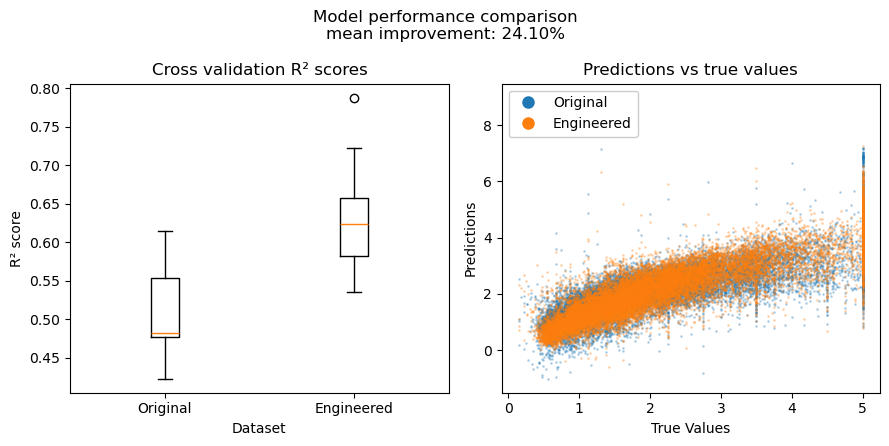

In [9]:
original_model = LinearRegression()
original_model.fit(original_housing_df.drop('MedHouseVal', axis=1), original_housing_df['MedHouseVal'])
original_predictions = original_model.predict(original_housing_df.drop('MedHouseVal', axis=1))

model = LinearRegression()
model.fit(housing_df.drop('MedHouseVal', axis=1), housing_df['MedHouseVal'])
predictions = model.predict(housing_df.drop('MedHouseVal', axis=1))

# Create boxplot comparing performance
data_to_plot = [scores_original, scores_engineered]
labels = ['Original', 'Engineered']

fig, axs = plt.subplots(1, 2, figsize=(9,4.5))

fig.suptitle(f'Model performance comparison\nmean improvement: {mean_improvement:.2f}%')

axs[0].set_title('Cross validation R² scores')
axs[0].boxplot(data_to_plot, tick_labels=labels)
axs[0].set_xlabel('Dataset')
axs[0].set_ylabel('R² score')

axs[1].set_title('Predictions vs true values')
axs[1].plot(
    original_housing_df['MedHouseVal'], original_predictions,
    'o', markersize=1, label='Original', alpha=0.25
)

axs[1].plot(
    housing_df['MedHouseVal'], predictions,
    'o', markersize=1, label='Engineered', alpha=0.25
)

axs[1].set_xlabel('True Values')
axs[1].set_ylabel('Predictions')

leg = axs[1].legend(loc='upper left', markerscale=8, framealpha=1)

for lh in leg.legend_handles:
    lh.set_alpha(1)

plt.tight_layout()
plt.show()

## 3. Reflection

**Questions to consider**:

1. Which feature engineering techniques had the biggest impact on model performance?
2. Did adding more features always improve performance, or did some hurt it?
3. How might you further improve the engineered dataset?
4. What trade-offs did you consider (e.g., interpretability vs performance, complexity vs gains)?

### Answers

**1. Biggest impact.** Three groups of features drove the gain (final result: **~24% improvement in cross-validated R²**):
- *Log transforms* of the skewed features (`MedInc`, `AveOccup`, `AveRooms`, `AveBedrms`, `Population`) gave the first few points by taming extreme outliers.
- *Polynomial terms* — especially squared/cubed income and the degree-2 geographic terms (`lat2`, `lon2`, `latlon`) — gave the largest single jump, because they let the linear model fit the curved relationship between income/location and value.
- *Interaction terms* (`income_x_*`, `occup_x_income`, `age_x_income`) added the final points by letting income's effect vary with location, crowding, and building age.

**2. More features did NOT always help.** This was the key lesson. High-cardinality encodings — a geographic grid one-hot (10×10 to 25×25 cells) and RBF/cluster location features — actually *hurt* the score, sometimes badly (a 20×20 grid dropped R² by ~50%). Plain `LinearRegression` has no regularization, so dozens of sparse/noisy columns cause it to overfit within the cross-validation folds. Every feature in the final set was kept only if it improved 10-fold CV R².

**3. Further improvements.** The biggest remaining gains would come from changing the *model* rather than the features: a regularized linear model (Ridge/Lasso) would let us safely add the geographic grid and RBF features that overfit plain OLS, and tree-based models (Gradient Boosting / Random Forest) would capture the geographic non-linearity automatically. Target/leave-one-out encoding of geographic bins (done inside a CV pipeline to avoid leakage) is another promising direction.

**4. Trade-offs.** The main trade-off was **complexity/flexibility vs. overfitting**. With un-regularized OLS, more flexibility (more features) quickly backfires, so the final set is deliberately compact (~25 features) and every term is interpretable (a power or an interaction of existing features) rather than an opaque encoding. We favored features with a clear real-world justification, which keeps the model explainable while still capturing the dataset's non-linear structure.
